In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

In [3]:
# Load processed dataset
df = pd.read_csv("../data/processed/processed_news.csv")

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (38653, 2)


,content,label
0,ben stein call th circuit court committed ‘cou...,1
1,trump drop steve bannon national security coun...,0
2,puerto rico expects u lift jones act shipping ...,0
3,oops trump accidentally confirmed leaked israe...,1
4,donald trump head scotland reopen golf resort ...,0


In [4]:
df.columns

Index(['content', 'label'], dtype='str')

In [6]:
print(df.columns.tolist())

['content', 'label']


In [7]:
# Features and target
X = df["content"]
y = df["label"]

# Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Validation (10%) and Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2/3,
    stratify=y_temp,
    random_state=42
)

print("Training samples :", len(X_train))
print("Validation samples :", len(X_val))
print("Testing samples :", len(X_test))

Training samples : 27057
Validation samples : 3865
Testing samples : 7731


In [8]:
print("Training Set")
print(y_train.value_counts(normalize=True))

print("\nValidation Set")
print(y_val.value_counts(normalize=True))

print("\nTest Set")
print(y_test.value_counts(normalize=True))

Training Set
label
0    0.548361
1    0.451639
Name: proportion, dtype: float64

Validation Set
label
0    0.548254
1    0.451746
Name: proportion, dtype: float64

Test Set
label
0    0.548441
1    0.451559
Name: proportion, dtype: float64


In [9]:
# Load the pre-trained Sentence Transformer model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully!")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7164.16it/s]


Model loaded successfully!


# Generate Sentence Embeddings

The Sentence Transformer converts each article into a dense vector representation.

Unlike TF-IDF, these embeddings capture the semantic meaning of the entire article rather than simply counting word occurrences.

Embeddings are generated separately for the training, validation, and test sets to maintain the same evaluation pipeline used in the classical machine learning approach.

In [10]:
# Generate sentence embeddings

print("Generating training embeddings...")
X_train_embeddings = embedding_model.encode(
    X_train.tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Generating validation embeddings...")
X_val_embeddings = embedding_model.encode(
    X_val.tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Generating testing embeddings...")
X_test_embeddings = embedding_model.encode(
    X_test.tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

Generating training embeddings...


Batches: 100%|██████████| 846/846 [16:15<00:00,  1.15s/it]  


Generating validation embeddings...


Batches: 100%|██████████| 121/121 [02:29<00:00,  1.23s/it]


Generating testing embeddings...


Batches: 100%|██████████| 242/242 [05:23<00:00,  1.34s/it]


# Train the Linear SVM Classifier

The Sentence Transformer has converted each news article into a dense semantic embedding.

These embeddings are used as input features for a Linear Support Vector Machine (Linear SVM).

Linear SVM is chosen because it performs well on high-dimensional feature representations and provides a strong baseline for text classification while remaining computationally efficient.

In [11]:
# Initialize the classifier
svm_model = LinearSVC(random_state=42)

# Train the model
svm_model.fit(X_train_embeddings, y_train)

print("Linear SVM trained successfully!")

Linear SVM trained successfully!


In [12]:
# Validation predictions
y_val_pred = svm_model.predict(X_val_embeddings)

# Evaluation metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")

Accuracy : 0.9731
Precision: 0.9735
Recall   : 0.9668
F1 Score : 0.9701


In [13]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2119
           1       0.97      0.97      0.97      1746

    accuracy                           0.97      3865
   macro avg       0.97      0.97      0.97      3865
weighted avg       0.97      0.97      0.97      3865



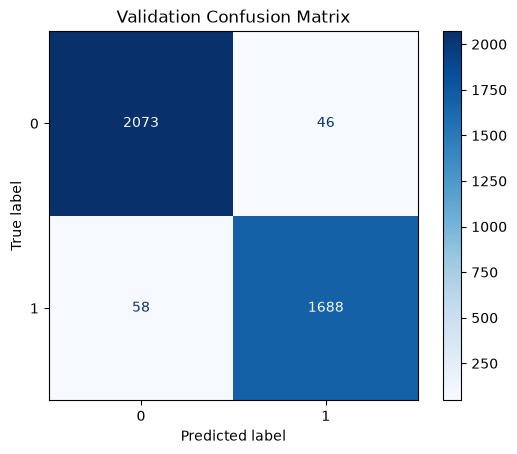

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    cmap="Blues"
)

plt.title("Validation Confusion Matrix")
plt.show()

In [15]:
# Test predictions
y_test_pred = svm_model.predict(X_test_embeddings)

# Evaluation metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Accuracy : 0.9750
Precision: 0.9785
Recall   : 0.9659
F1 Score : 0.9722


In [16]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4240
           1       0.98      0.97      0.97      3491

    accuracy                           0.98      7731
   macro avg       0.98      0.97      0.97      7731
weighted avg       0.98      0.98      0.98      7731



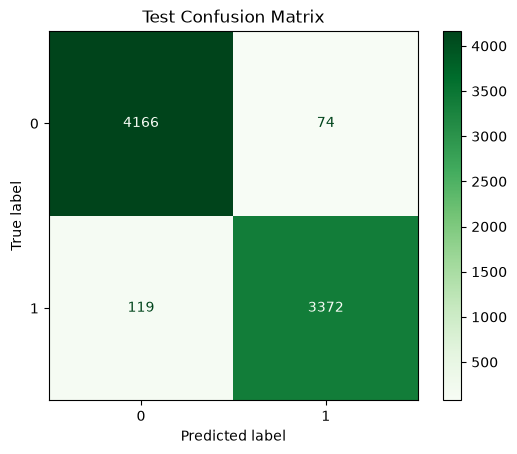

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap="Greens"
)

plt.title("Test Confusion Matrix")
plt.show()

In [18]:
import os
import joblib

# Create artifacts directory if it doesn't exist
os.makedirs("../artifacts", exist_ok=True)

# Save trained classifier
joblib.dump(svm_model, "../artifacts/sentence_transformer_svm.pkl")

# Save embedding model name
with open("../artifacts/sentence_transformer_model.txt", "w") as f:
    f.write("all-MiniLM-L6-v2")

print("Artifacts saved successfully!")

Artifacts saved successfully!


In [19]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Linear SVM",
        "MiniLM Embeddings + Linear SVM"
    ],
    "Feature Representation": [
        "Sparse TF-IDF",
        "Dense Semantic Embeddings"
    ],
    "Accuracy": [
        0.9953,
        round(test_accuracy,4)
    ],
    "Precision": [
        0.9974,
        round(test_precision,4)
    ],
    "Recall": [
        0.9923,
        round(test_recall,4)
    ],
    "F1 Score": [
        0.9948,
        round(test_f1,4)
    ]
})

comparison

,Model,Feature Representation,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Linear SVM,Sparse TF-IDF,0.9953,0.9974,0.9923,0.9948
1,MiniLM Embeddings + Linear SVM,Dense Semantic Embeddings,0.9750,0.9785,0.9659,0.9722


# Engineering Insights

This notebook compares two different approaches for fake news classification.

The first approach uses TF-IDF with Linear SVM, while the second uses transformer-generated sentence embeddings with the same classifier.

Although the transformer-based approach provides semantic representations of the articles, the TF-IDF model achieved higher performance on this dataset.

This highlights an important machine learning principle: a more advanced model does not always produce better results. Model selection should depend on the dataset characteristics, computational cost, and deployment requirements.

The Sentence Transformer approach remains valuable because it captures contextual meaning, requires minimal manual feature engineering, and can generalize better to tasks where semantic understanding is more important than word frequency.